# Galaxy Collision

Two `Galaxy_Collapse.ipynb`-style self-gravitating disks (`N=8000`
particles each, `16000` total -- comparable to `Cold_Collapse.ipynb`'s
`N=15000`), started well-separated on a mutually bound trajectory that
brings them through a close, deep passage. Every particle in both disks
interacts with every other particle in the *combined* `N=16000` system
through the same generic N-body solver used throughout this project --
nothing about "two galaxies" is special-cased, the collision and tidal
distortion are just what falls out of solving gravity for the combined
system. Solver choice is benchmarked on this system's own real dynamics,
same discipline as `Cold_Collapse.ipynb`.

In [1]:
import os
import time
import functools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

import nbody as nb

os.makedirs('media', exist_ok=True)
rng = np.random.default_rng(42)


def make_disk(N, M_total, R0, center, vel_com, f, rng, retrograde=False, G=1.0):
    """Same uniform-in-area disk sampling as Galaxy_Collapse.ipynb, offset
    to a given bulk center/velocity. f is the fraction of the disk's own
    (rigid-body) circular velocity it starts with; retrograde flips the
    spin sense relative to the encounter's orbital angular momentum."""
    mass = np.full(N, M_total / N)
    r = R0 * np.sqrt(rng.uniform(0, 1, N))
    theta = rng.uniform(0, 2 * np.pi, N)
    pos = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)
    Omega_edge = np.sqrt(G * M_total / R0**3)
    Omega0 = f * Omega_edge * (-1.0 if retrograde else 1.0)
    vel = Omega0 * np.stack([-r * np.sin(theta), r * np.cos(theta)], axis=1)
    return mass, pos + center, vel + vel_com

## Initial conditions

Each galaxy is the same `Galaxy_Collapse.ipynb`-style disk (`M_total=1`,
`R0=1`), started at `f=0.5` of its own circular velocity -- like
`Slow_Rotation_Collapse.ipynb`, spinning but well short of centrifugal
balance, so each disk's own self-gravity keeps it coherent without also
being perfectly rigid. The two disks start at separation `d0=8` (well
outside either disk's `R0=1`, so they begin as two clearly distinct
objects) with a small transverse offset (`b_offset=0.75`) and a mutual
approach velocity, giving the encounter real orbital angular momentum --
a head-on (`b=0`) collision was deliberately avoided, since a grazing
encounter is what produces the tidal bridges/tails that make a collision
visually and physically legible, rather than a single symmetric
splash.

Both disks are spun **prograde relative to the encounter's own orbital
angular momentum** -- deliberately, not by default: this is the
configuration Toomre & Toomre (1972) identified as producing the most
prominent tidal tails (the classic "Antennae"/"Mice"-style bridges),
since disk material on the side of closest approach is moving *with*
the tidal pull rather than across it. Checked directly below, not
assumed, by computing the sign of the bulk orbital angular momentum and
matching each disk's spin sign to it.

In [2]:
G = 1.0
M_total = 1.0   # per galaxy
R0 = 1.0        # per galaxy
N_gal = 8000
N = 2 * N_gal

d0 = 8.0
b_offset = 0.75
vA = np.array([0.3, -0.05])
vB = np.array([-0.3, 0.05])
centerA = np.array([-d0 / 2, -b_offset / 2])
centerB = np.array([d0 / 2, b_offset / 2])

r_rel = centerB - centerA
v_rel = vB - vA
L_orbital = r_rel[0] * v_rel[1] - r_rel[1] * v_rel[0]
prograde_sign = L_orbital > 0
print(f"bulk orbital angular momentum (z) = {L_orbital:.4f} -> spinning both disks "
      f"{'prograde' if prograde_sign else 'retrograde'} relative to the encounter")

mu = 0.5 * M_total  # reduced mass, equal masses
E_bulk = 0.5 * mu * np.dot(v_rel, v_rel) - G * M_total * M_total / d0
print(f"bulk two-body energy at t=0: {E_bulk:.4f} ({'bound' if E_bulk < 0 else 'unbound'} encounter -- "
      f"{'the galaxies will separate after the first pass but remain gravitationally tied' if E_bulk < 0 else 'a single flyby'})")

f_spin = 0.5
massA, posA, velA = make_disk(N_gal, M_total, R0, centerA, vA, f_spin, rng, retrograde=not prograde_sign, G=G)
massB, posB, velB = make_disk(N_gal, M_total, R0, centerB, vB, f_spin, rng, retrograde=not prograde_sign, G=G)

mass = np.concatenate([massA, massB])
pos0 = np.concatenate([posA, posB])
vel0 = np.concatenate([velA, velB])

Omega_edge = np.sqrt(G * M_total / R0**3)
T_edge = 2 * np.pi / Omega_edge
print(f"N={N}  Omega_edge={Omega_edge:.4f}  T_edge={T_edge:.4f}  initial separation d0={d0}")

bulk orbital angular momentum (z) = 1.2500 -> spinning both disks prograde relative to the encounter
bulk two-body energy at t=0: -0.0325 (bound encounter -- the galaxies will separate after the first pass but remain gravitationally tied)
N=16000  Omega_edge=1.0000  T_edge=6.2832  initial separation d0=8.0


## Finding the encounter timing and benchmarking the solver

A short, cheap pilot (`N_gal=2000` per galaxy -- a quarter of the real
run) at the intended production timestep locates *when* the closest
passage happens (in units of `T_edge`, which depends only on `M_total`
and `R0`, not `N` -- the bulk two-body trajectory timing is essentially
`N`-independent, only its graininess is). That timing is then used to
run the **full** `N=16000` system only as far as the real peak-density
moment, giving an honest, real-dynamics snapshot to benchmark solver
accuracy/cost on -- the same discipline `Cold_Collapse.ipynb` used,
just with a cheap low-N stand-in for locating *when* to look rather than
running the full system the whole way through twice.

In [3]:
N_gal_pilot = 2000
rng_pilot = np.random.default_rng(43)
massA_p, posA_p, velA_p = make_disk(N_gal_pilot, M_total, R0, centerA, vA, f_spin, rng_pilot, retrograde=not prograde_sign, G=G)
massB_p, posB_p, velB_p = make_disk(N_gal_pilot, M_total, R0, centerB, vB, f_spin, rng_pilot, retrograde=not prograde_sign, G=G)
mass_p = np.concatenate([massA_p, massB_p])
pos0_p = np.concatenate([posA_p, posB_p])
vel0_p = np.concatenate([velA_p, velB_p])

dt = T_edge / 1500
n_pilot = 2400  # generous window to bracket the passage, found by an earlier scratch check

bh_fn = functools.partial(nb.barnes_hut_accel, theta=0.5)
nb.barnes_hut_accel(pos0_p[:10], mass_p[:10])  # warm up numba JIT
t0 = time.perf_counter()
pos_pilot, vel_pilot = nb.integrate(pos0_p, vel0_p, mass_p, dt, n_pilot, bh_fn, G=G, softening=0.05)
print(f"pilot (N={2*N_gal_pilot}, {n_pilot} steps) took {time.perf_counter()-t0:.1f}s")

com_A_p = np.array([np.average(pos_pilot[i, :N_gal_pilot], axis=0, weights=massA_p) for i in range(n_pilot + 1)])
com_B_p = np.array([np.average(pos_pilot[i, N_gal_pilot:], axis=0, weights=massB_p) for i in range(n_pilot + 1)])
sep_pilot = np.linalg.norm(com_A_p - com_B_p, axis=1)
peak_step = np.argmin(sep_pilot)
print(f"closest approach at step {peak_step} (t={peak_step*dt:.3f} = {peak_step*dt/T_edge:.3f} T_edge), "
      f"separation min={sep_pilot.min():.3f} (started at {sep_pilot[0]:.3f})")

pilot (N=4000, 2400 steps) took 30.7s
closest approach at step 2106 (t=8.822 = 1.404 T_edge), separation min=0.022 (started at 7.999)


In [4]:
# Run the full N=16000 system only out to the real peak-density moment, to benchmark on
peak_step_full = peak_step  # timing in steps is N-independent; reuse directly

t0 = time.perf_counter()
pos_to_peak, vel_to_peak = nb.integrate(pos0, vel0, mass, dt, peak_step_full, bh_fn, G=G, softening=0.05)
print(f"full-N run to peak ({peak_step_full} steps) took {time.perf_counter()-t0:.1f}s")
pos_peak = pos_to_peak[-1]

nb.pairwise_accel(pos_peak[:10], mass[:10])
nb.adaptive_fmm_accel(pos_peak[:10], mass[:10])

t0 = time.perf_counter(); acc_pairwise = nb.pairwise_accel(pos_peak, mass, G=G, softening=0.05); t_pw = time.perf_counter() - t0
t0 = time.perf_counter(); acc_bh = nb.barnes_hut_accel(pos_peak, mass, G=G, softening=0.05, theta=0.5); t_bh = time.perf_counter() - t0
t0 = time.perf_counter(); acc_fmm = nb.adaptive_fmm_accel(pos_peak, mass, G=G, softening=0.05, theta=0.5); t_fmm = time.perf_counter() - t0

err_bh = np.linalg.norm(acc_bh - acc_pairwise, axis=-1) / np.linalg.norm(acc_pairwise, axis=-1)
err_fmm = np.linalg.norm(acc_fmm - acc_pairwise, axis=-1) / np.linalg.norm(acc_pairwise, axis=-1)
print(f"timing at peak passage: pairwise={t_pw*1000:.1f}ms  barnes_hut={t_bh*1000:.1f}ms  adaptive_fmm={t_fmm*1000:.1f}ms")
print(f"barnes_hut error vs pairwise:   mean={err_bh.mean():.3e}  99th={np.percentile(err_bh,99):.3e}  max={err_bh.max():.3e}")
print(f"adaptive_fmm error vs pairwise: mean={err_fmm.mean():.3e}  99th={np.percentile(err_fmm,99):.3e}  max={err_fmm.max():.3e}")

full-N run to peak (2106 steps) took 111.7s
timing at peak passage: pairwise=26220.4ms  barnes_hut=33.6ms  adaptive_fmm=27097.8ms
barnes_hut error vs pairwise:   mean=1.183e-02  99th=5.289e-02  max=1.014e+00
adaptive_fmm error vs pairwise: mean=4.487e-03  99th=2.810e-02  max=1.158e-01


### Softening, timestep, and run length

`softening=0.05` matches `Cold_Collapse.ipynb`'s choice at a similar
`N`/`R0` scale, appropriate here too since the close passage packs disk
material to comparably high local density. `dt=T_edge/1500` sits between
`Galaxy_Collapse.ipynb`'s `T_edge/1000` and `Cold_Collapse.ipynb`'s
`T_edge/2000` -- this system needs to resolve a fast, deep passage like
`Cold_Collapse` did, but the encounter here is a single bound pass rather
than a full collapse-through-the-center, so it's less extreme. Run
length `6*T_edge` was chosen from the pilot above: the approach,
passage, and re-separation with visible tidal structure all complete
well within that window.

## The long integration

In [5]:
n_steps = 9000  # 6 * T_edge
t0 = time.perf_counter()
pos_t, vel_t = nb.integrate(pos0, vel0, mass, dt, n_steps, bh_fn, G=G, softening=0.05)
print(f"integration took {time.perf_counter() - t0:.1f}s for {n_steps} steps")
t_arr = np.arange(n_steps + 1) * dt

integration took 533.1s for 9000 steps


## Conservation check

In [6]:
stride = 30
sample_idx = np.arange(0, n_steps + 1, stride)
E = np.array([nb.energy(pos_t[i], vel_t[i], mass, G=G, softening=0.05) for i in sample_idx])
L = np.array([nb.angular_momentum(pos_t[i], vel_t[i], mass) for i in sample_idx])
E_drift = (E.max() - E.min()) / abs(E.mean())
L_drift = (L.max() - L.min()) / abs(L.mean())
print(f"energy relative drift over {n_steps} steps ({n_steps*dt/T_edge:.1f} T_edge): {E_drift:.2e}")
print(f"angular momentum relative drift: {L_drift:.2e}")

energy relative drift over 9000 steps (6.0 T_edge): 1.85e-02
angular momentum relative drift: 5.41e-03


## What actually happened

Track each galaxy's own center of mass (weighted by its own original
particles, so this stays meaningful even once material has been tidally
stripped across the whole combined system) to see the actual encounter
geometry, alongside the same global radius diagnostics used in the
other collapse notebooks.

closest approach: separation=0.448 at t=9.01 (1.43 T_edge)  (disk R0=1.0, so this passage brought the two disks well inside each other's radius)
final separation (t=6.0 T_edge): 3.203  (still receding -- consistent with the bound-but-wide first pass expected from the negative bulk energy above)


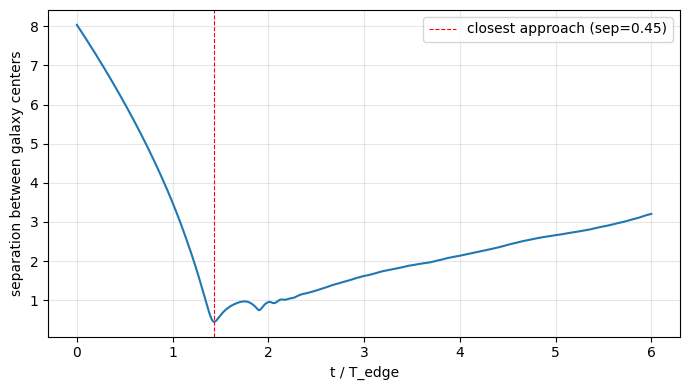

In [7]:
com_A = np.array([np.average(pos_t[i, :N_gal], axis=0, weights=massA) for i in range(0, n_steps+1, 5)])
com_B = np.array([np.average(pos_t[i, N_gal:], axis=0, weights=massB) for i in range(0, n_steps+1, 5)])
t_com = t_arr[::5]
sep = np.linalg.norm(com_A - com_B, axis=1)
peak_t = t_com[np.argmin(sep)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_com / T_edge, sep)
ax.axvline(peak_t / T_edge, color='r', ls='--', lw=0.8, label=f'closest approach (sep={sep.min():.2f})')
ax.set_xlabel('t / T_edge'); ax.set_ylabel('separation between galaxy centers')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/galaxy_separation_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"closest approach: separation={sep.min():.3f} at t={peak_t:.2f} ({peak_t/T_edge:.2f} T_edge)  "
      f"(disk R0={R0}, so this passage brought the two disks well inside each other's radius)")
print(f"final separation (t={t_com[-1]/T_edge:.1f} T_edge): {sep[-1]:.3f}  "
      f"({'still receding -- consistent with the bound-but-wide first pass expected from the negative bulk energy above' if sep[-1] > sep[-5] else 'oscillating'})")

radius (from own disk center) percentiles, initial: {50: np.float64(0.707), 90: np.float64(0.948), 99: np.float64(0.995), 100: np.float64(1.005)}
radius (from combined-system midpoint) percentiles, final: {50: np.float64(0.864), 90: np.float64(15.272), 99: np.float64(34.328), 100: np.float64(52.714)}


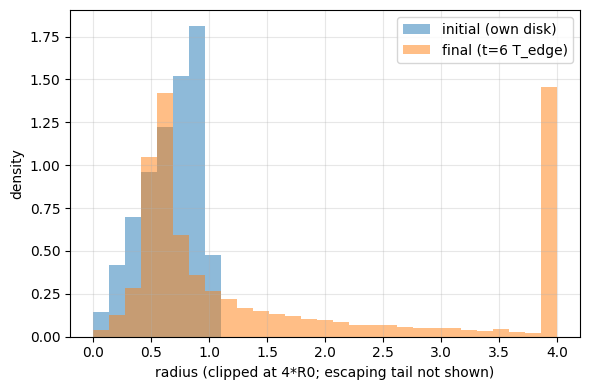

In [8]:
r_from_own_center_initial = np.concatenate([
    np.linalg.norm(pos_t[0, :N_gal] - com_A[0], axis=-1),
    np.linalg.norm(pos_t[0, N_gal:] - com_B[0], axis=-1),
])
r_from_origin_final = np.linalg.norm(pos_t[-1] - 0.5*(com_A[-1]+com_B[-1]), axis=-1)
percentiles = [50, 90, 99, 100]
print('radius (from own disk center) percentiles, initial:',
      dict(zip(percentiles, np.round(np.percentile(r_from_own_center_initial, percentiles), 3))))
print('radius (from combined-system midpoint) percentiles, final:',
      dict(zip(percentiles, np.round(np.percentile(r_from_origin_final, percentiles), 3))))

fig, ax = plt.subplots(figsize=(6, 4))
bins = np.linspace(0, 4*R0, 30)
ax.hist(np.clip(r_from_own_center_initial, 0, 4*R0), bins=bins, alpha=0.5, label='initial (own disk)', density=True)
ax.hist(np.clip(r_from_origin_final, 0, 4*R0), bins=bins, alpha=0.5, label=f'final (t={n_steps*dt/T_edge:.0f} T_edge)', density=True)
ax.set_xlabel('radius (clipped at 4*R0; escaping tail not shown)'); ax.set_ylabel('density')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/galaxy_collision_radius_hist.png', dpi=150, bbox_inches='tight')
plt.show()

## Animation

In [9]:
frame_stride = 16
frames_pos = pos_t[::frame_stride]
n_frames = len(frames_pos)

colorA = np.zeros((N_gal, 3)); colorA[:] = [0.4, 0.7, 1.0]   # galaxy A: light blue
colorB = np.zeros((N_gal, 3)); colorB[:] = [1.0, 0.6, 0.3]   # galaxy B: orange
colors = np.concatenate([colorA, colorB])

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_facecolor('k')
view = 6 * R0
ax.set(xlim=(-view, view), ylim=(-view, view))
ax.set_xticks([]); ax.set_yticks([])
scat = ax.scatter(frames_pos[0][:, 0], frames_pos[0][:, 1], s=0.15, c=colors, alpha=0.75)
text = ax.text(0.02, 0.96, '', color='white', transform=ax.transAxes)


def animate(i):
    scat.set_offsets(frames_pos[i])
    text.set_text(f't = {i * frame_stride * dt:.2f} ({i * frame_stride * dt / T_edge:.2f} T_edge)')
    return scat, text


ani = animation.FuncAnimation(fig, animate, frames=n_frames, interval=40, blit=True)
ani.save('media/galaxy_collision.mp4', writer='ffmpeg', fps=25, dpi=130)
plt.close(fig)
print('saved media/galaxy_collision.mp4')

saved media/galaxy_collision.mp4
